# Care Pipeline Analysis

## Objective

Analyze the movement of children through the UAC care pipeline and evaluate the relationship between inflows and outflows across CBP custody and HHS care.

## Business Questions

- How efficiently are children transferred out of CBP custody?
- How does HHS discharge activity compare with the number of children in HHS care?
- Is the overall pipeline maintaining a balance between inflows and outflows?
- Where do periods of operational pressure occur?
- Are periods of pressure temporary or sustained over time?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/uac_cleaned.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,apprehended,cbp_custody,transferred,hhs_care,discharged
0,2023-01-12,33.0,53.0,34.0,6566,436.0
1,2023-01-22,32.0,49.0,39.0,7122,227.0
2,2023-01-23,32.0,50.0,39.0,7280,181.0
3,2023-01-24,47.0,42.0,47.0,7433,175.0
4,2023-01-25,20.0,22.0,41.0,7538,180.0


## 4.1 Care Pipeline Overview

### Business Question

What is the overall scale of activity across the major stages of the UAC care pipeline?

### Description

The UAC care pipeline consists of apprehension and CBP custody, transfer to HHS care, and eventual discharge from HHS care.

Comparing the average values across these stages provides a high-level view of the scale of activity recorded at each stage of the pipeline.

In [2]:
pipeline_totals = {
    "Apprehended": df["apprehended"].mean(),
    "CBP Custody": df["cbp_custody"].mean(),
    "Transferred": df["transferred"].mean(),
    "HHS Care": df["hhs_care"].mean(),
    "Discharged": df["discharged"].mean()
}

pipeline_summary = pd.Series(pipeline_totals)

pipeline_summary

Apprehended      93.523611
CBP Custody     171.494444
Transferred     128.668056
HHS Care       6061.275000
Discharged      173.406944
dtype: float64

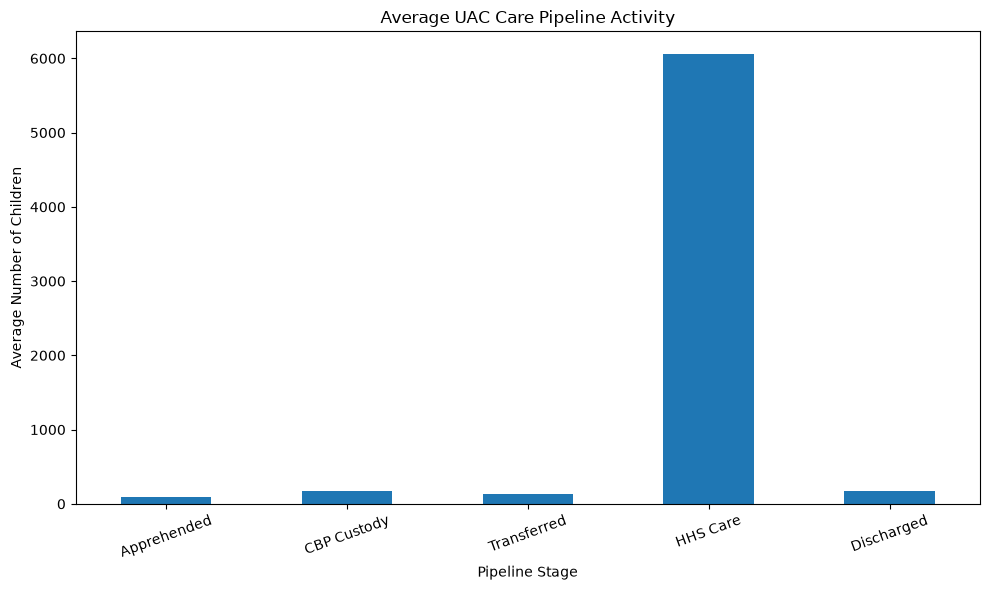

In [3]:
plt.figure(figsize=(10, 6))

pipeline_summary.plot(kind="bar")

plt.title("Average UAC Care Pipeline Activity")
plt.xlabel("Pipeline Stage")
plt.ylabel("Average Number of Children")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Figure 1: Average UAC Care Pipeline Activity

### Key Finding

The average population recorded in HHS care is substantially larger than the CBP custody population, while transfer and discharge represent the major outflow activities recorded in the dataset.

### Business Implication

The difference in scale between pipeline stages should be considered when evaluating operational pressure and efficiency. CBP and HHS activity should not be interpreted as operating at the same population level.

## 4.2 CBP-to-HHS Transfer Efficiency

### Business Question

How does transfer activity compare with the number of children in CBP custody?

### Description

The Transfer Efficiency Ratio is calculated by comparing children transferred out of CBP custody with children recorded in CBP custody.

This provides an aggregate measure of transfer activity during each reporting period.

Because the dataset does not contain individual transfer timestamps, this ratio should not be interpreted as an actual transfer processing time.

In [4]:
df["transfer_efficiency"] = np.where(
    df["cbp_custody"] > 0,
    df["transferred"] / df["cbp_custody"],
    np.nan
)

df[["date", "cbp_custody", "transferred", "transfer_efficiency"]].head()

,date,cbp_custody,transferred,transfer_efficiency
0,2023-01-12,53.0,34.0,0.641509
1,2023-01-22,49.0,39.0,0.795918
2,2023-01-23,50.0,39.0,0.780000
3,2023-01-24,42.0,47.0,1.119048
4,2023-01-25,22.0,41.0,1.863636


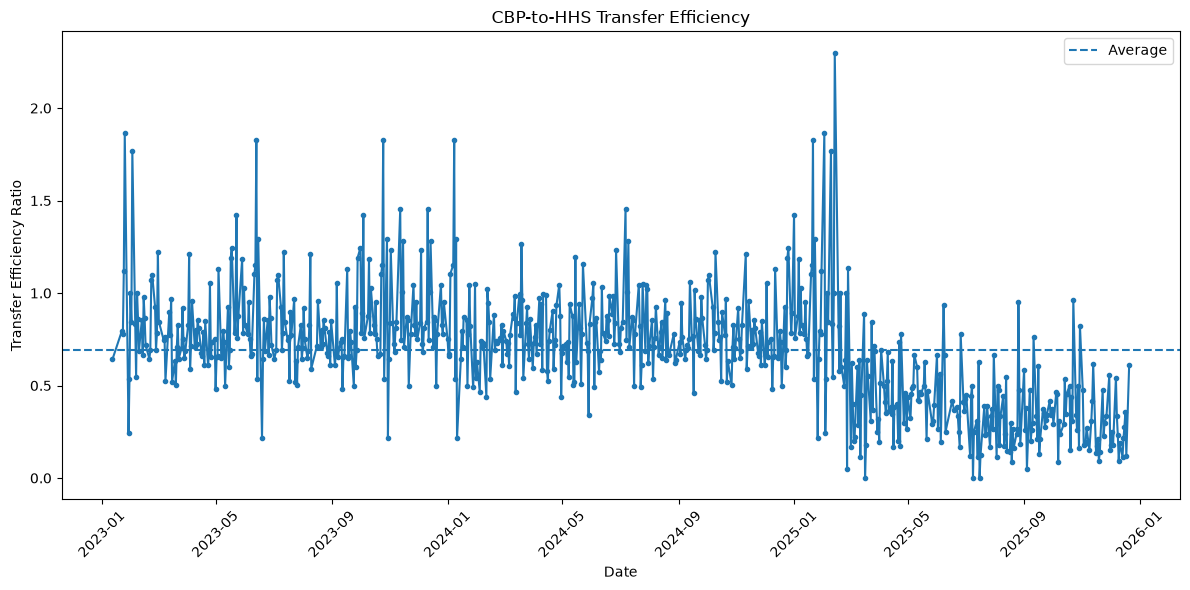

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["transfer_efficiency"],
    marker="o",
    markersize=3
)

plt.axhline(
    df["transfer_efficiency"].mean(),
    linestyle="--",
    label="Average"
)

plt.title("CBP-to-HHS Transfer Efficiency")
plt.xlabel("Date")
plt.ylabel("Transfer Efficiency Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 2: CBP-to-HHS Transfer Efficiency

### Key Finding

The transfer efficiency ratio varies across reporting periods, indicating that transfer activity does not remain constant relative to the CBP custody population.

### Business Implication

Periods with comparatively lower transfer activity can be flagged for further operational investigation, particularly when they occur alongside increased CBP pressure.

## 4.3 HHS Discharge Effectiveness

### Business Question

How does discharge activity compare with the number of children in HHS care?

### Description

The Discharge Effectiveness Index compares the number of children discharged from HHS care with the number of children recorded in HHS care.

This provides an aggregate measure of discharge activity relative to the HHS care population.

In [6]:
df["discharge_effectiveness"] = np.where(
    df["hhs_care"] > 0,
    df["discharged"] / df["hhs_care"],
    np.nan
)

df[["date", "hhs_care", "discharged", "discharge_effectiveness"]].head()

,date,hhs_care,discharged,discharge_effectiveness
0,2023-01-12,6566,436.0,0.066403
1,2023-01-22,7122,227.0,0.031873
2,2023-01-23,7280,181.0,0.024863
3,2023-01-24,7433,175.0,0.023544
4,2023-01-25,7538,180.0,0.023879


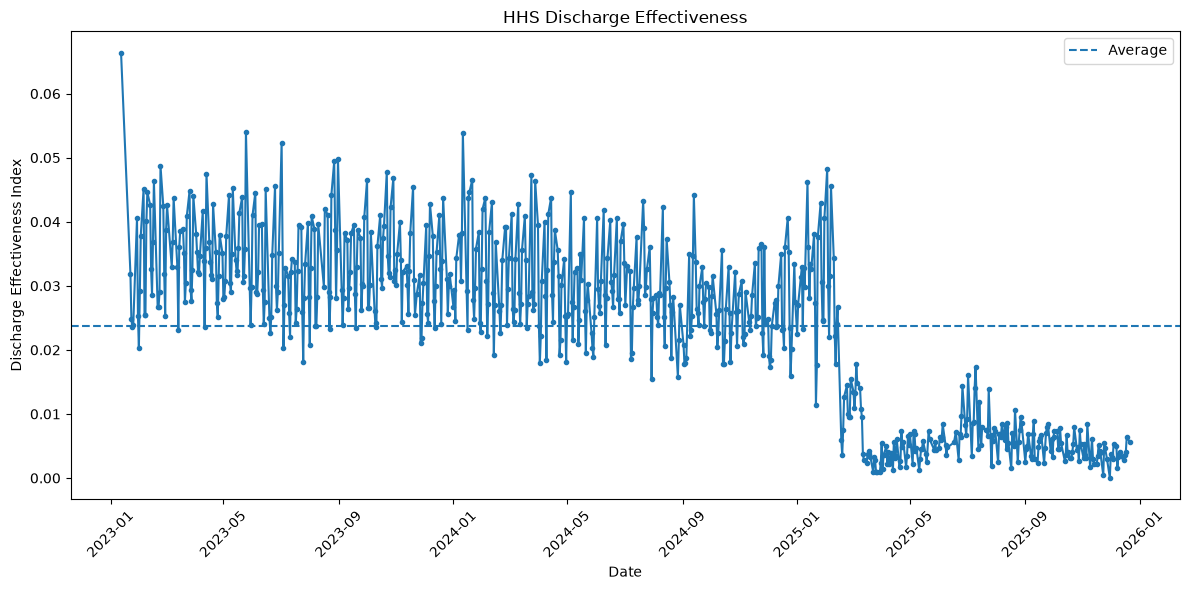

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["discharge_effectiveness"],
    marker="o",
    markersize=3
)

plt.axhline(
    df["discharge_effectiveness"].mean(),
    linestyle="--",
    label="Average"
)

plt.title("HHS Discharge Effectiveness")
plt.xlabel("Date")
plt.ylabel("Discharge Effectiveness Index")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 3: HHS Discharge Effectiveness

### Key Finding

Discharge effectiveness varies over the observation period, showing changes in discharge activity relative to the population recorded in HHS care.

### Business Implication

Monitoring discharge effectiveness can help identify periods where discharge activity is relatively low compared with the HHS care population.

## 4.4 Pipeline Throughput

### Business Question

How does overall pipeline outflow compare with pipeline inflow?

### Description

Pipeline throughput compares the total number of recorded exits with the total number of recorded entries.

For this analysis, apprehensions represent the primary recorded inflow, while discharges represent the final recorded outflow.

In [8]:
total_entries = df["apprehended"].sum()
total_exits = df["discharged"].sum()

pipeline_throughput = total_exits / total_entries

print("Total Entries:", total_entries)
print("Total Exits:", total_exits)
print("Pipeline Throughput:", pipeline_throughput)

Total Entries: 67337.0
Total Exits: 124853.0
Pipeline Throughput: 1.8541515066011256


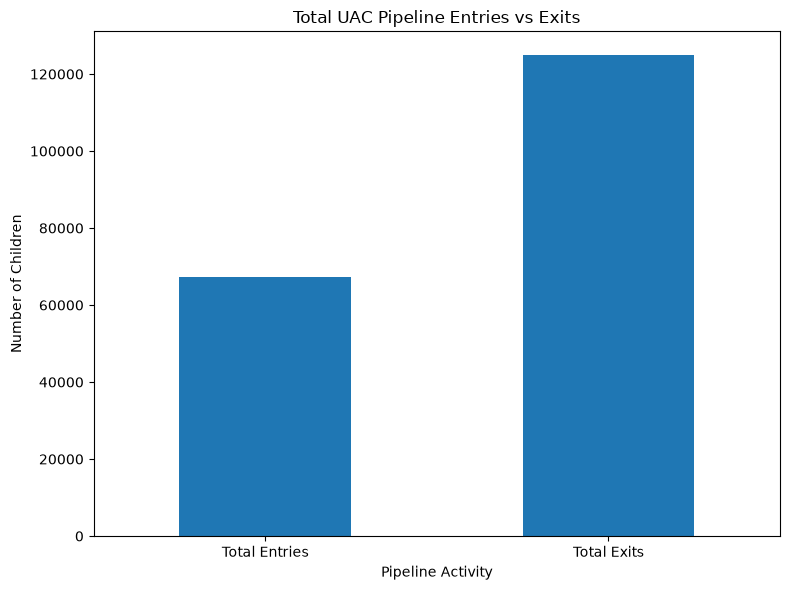

In [9]:
throughput_summary = pd.Series({
    "Total Entries": total_entries,
    "Total Exits": total_exits
})

plt.figure(figsize=(8, 6))

throughput_summary.plot(kind="bar")

plt.title("Total UAC Pipeline Entries vs Exits")
plt.xlabel("Pipeline Activity")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Figure 4: Total UAC Pipeline Entries vs Exits

### Key Finding

The comparison shows the overall relationship between recorded entries and exits during the observation period.

### Business Implication

Comparing cumulative inflows and outflows provides a high-level indication of whether activity leaving the recorded pipeline is keeping pace with incoming activity.

## 4.5 CBP Operational Pressure

### Business Question

When does incoming CBP activity exceed transfer activity?

### Description

CBP operational pressure is calculated as the difference between children apprehended and children transferred out of CBP custody.

Positive values indicate that recorded apprehensions exceeded transfers during a reporting period.

In [10]:
df["cbp_pressure"] = (
    df["apprehended"] - df["transferred"]
)

df[["date", "apprehended", "transferred", "cbp_pressure"]].head()

,date,apprehended,transferred,cbp_pressure
0,2023-01-12,33.0,34.0,-1.0
1,2023-01-22,32.0,39.0,-7.0
2,2023-01-23,32.0,39.0,-7.0
3,2023-01-24,47.0,47.0,0.0
4,2023-01-25,20.0,41.0,-21.0


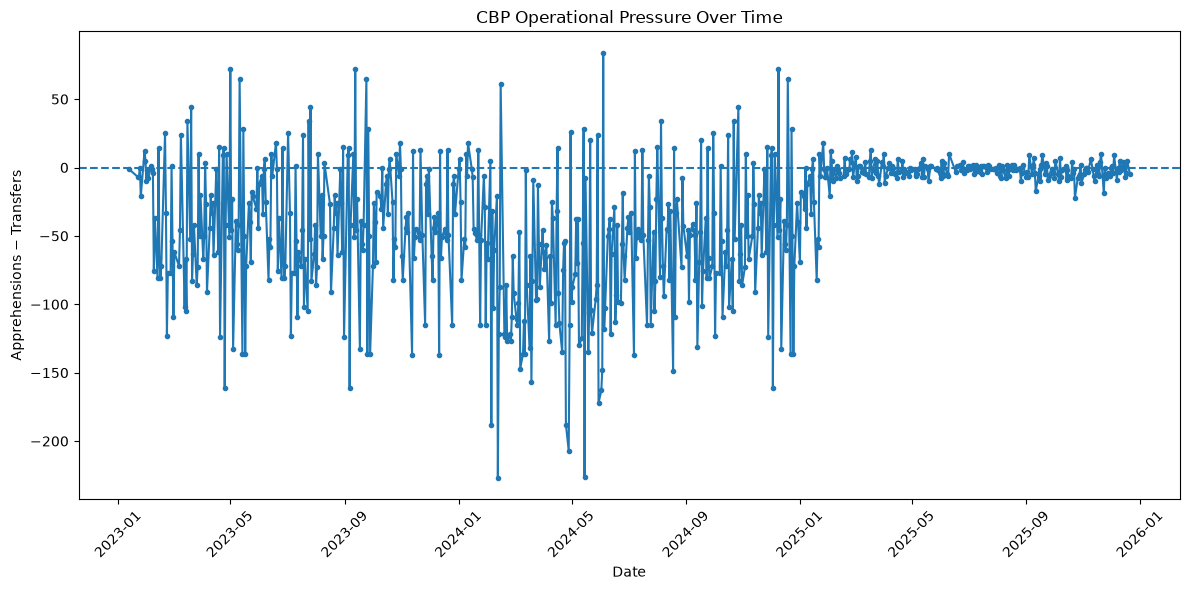

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["cbp_pressure"],
    marker="o",
    markersize=3
)

plt.axhline(0, linestyle="--")

plt.title("CBP Operational Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Apprehensions − Transfers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 5: CBP Operational Pressure Over Time

### Key Finding

CBP pressure fluctuates across reporting periods, with periods where apprehensions exceed transfers and periods where transfer activity is higher.

### Business Implication

Sustained positive pressure should be examined as a potential indication of increased operational demand within the CBP stage of the pipeline.

## 4.6 HHS Operational Pressure

### Business Question

When does incoming HHS activity exceed discharge activity?

### Description

HHS operational pressure is calculated as the difference between children transferred into HHS care and children discharged from HHS care.

Positive values indicate that recorded transfers exceeded recorded discharges during a reporting period.

In [12]:
df["hhs_pressure"] = (
    df["transferred"] - df["discharged"]
)

df[["date", "transferred", "discharged", "hhs_pressure"]].head()

,date,transferred,discharged,hhs_pressure
0,2023-01-12,34.0,436.0,-402.0
1,2023-01-22,39.0,227.0,-188.0
2,2023-01-23,39.0,181.0,-142.0
3,2023-01-24,47.0,175.0,-128.0
4,2023-01-25,41.0,180.0,-139.0


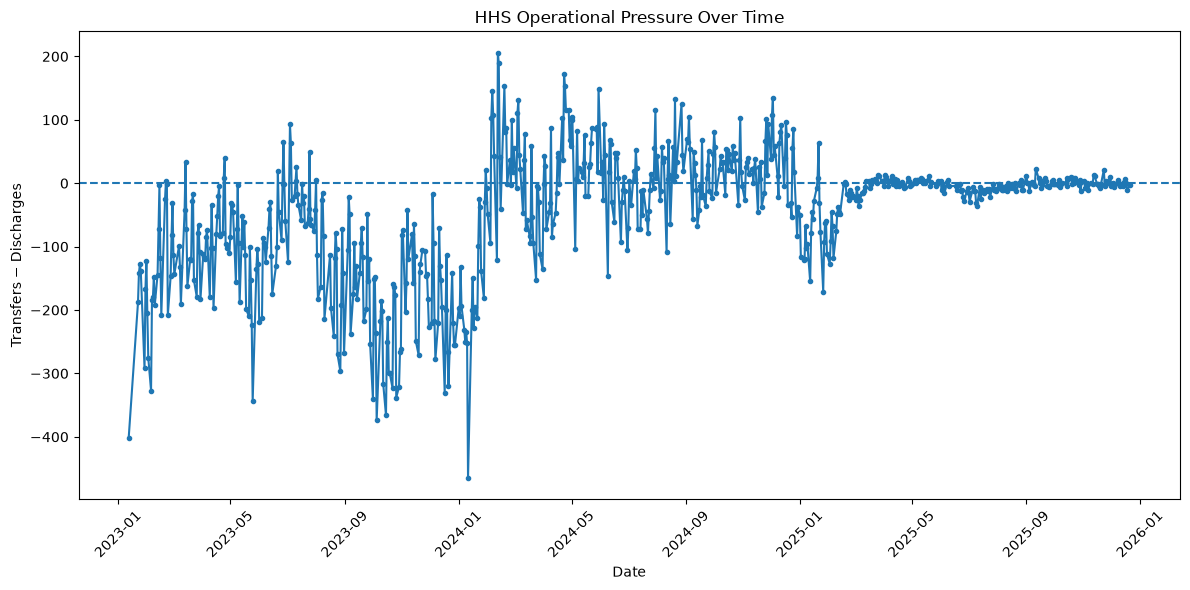

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["hhs_pressure"],
    marker="o",
    markersize=3
)

plt.axhline(0, linestyle="--")

plt.title("HHS Operational Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Transfers − Discharges")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 6: HHS Operational Pressure Over Time

### Key Finding

HHS pressure varies over time depending on the balance between transfers into HHS care and discharges from HHS care.

### Business Implication

Periods of sustained positive pressure can be prioritized for further investigation because incoming activity is exceeding discharge activity.

## 4.7 Cumulative Operational Pressure

### Business Question

Are periods of operational pressure temporary or sustained over multiple reporting periods?

### Description

Cumulative operational pressure tracks the running total of the difference between inflows and outflows.

This analysis helps identify sustained periods of imbalance rather than focusing only on individual reporting dates.

In [14]:
df["cumulative_cbp_pressure"] = (
    df["cbp_pressure"].cumsum()
)

df["cumulative_hhs_pressure"] = (
    df["hhs_pressure"].cumsum()
)

df[
    [
        "date",
        "cumulative_cbp_pressure",
        "cumulative_hhs_pressure"
    ]
].head()

,date,cumulative_cbp_pressure,cumulative_hhs_pressure
0,2023-01-12,-1.0,-402.0
1,2023-01-22,-8.0,-590.0
2,2023-01-23,-15.0,-732.0
3,2023-01-24,-15.0,-860.0
4,2023-01-25,-36.0,-999.0


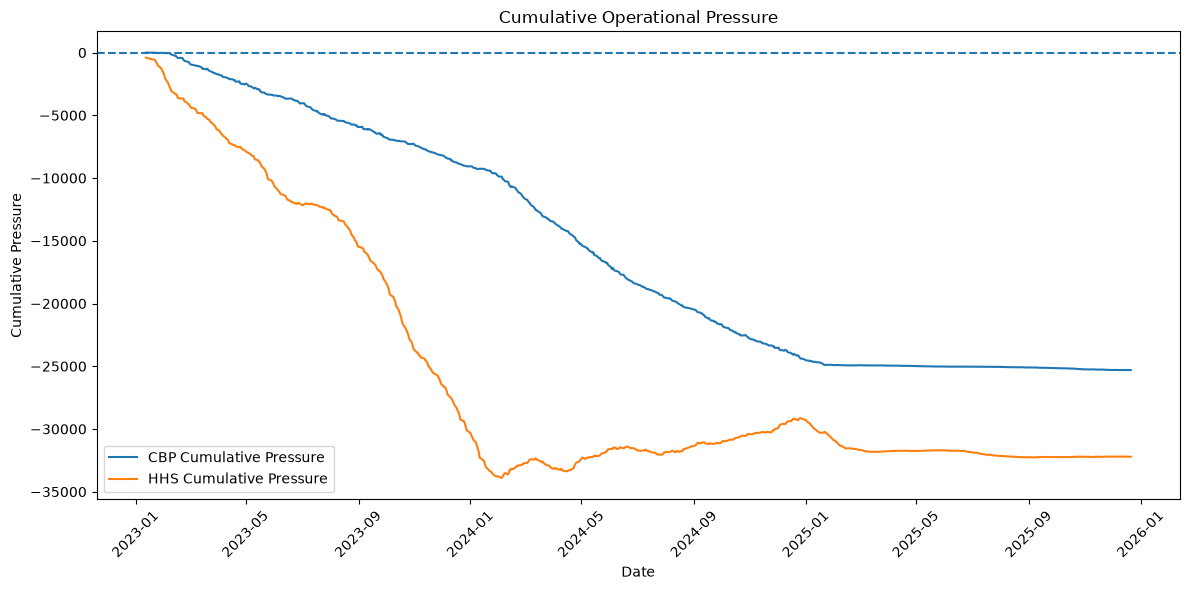

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["cumulative_cbp_pressure"],
    label="CBP Cumulative Pressure"
)

plt.plot(
    df["date"],
    df["cumulative_hhs_pressure"],
    label="HHS Cumulative Pressure"
)

plt.axhline(0, linestyle="--")

plt.title("Cumulative Operational Pressure")
plt.xlabel("Date")
plt.ylabel("Cumulative Pressure")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 7: Cumulative Operational Pressure

### Key Finding

Cumulative pressure highlights whether differences between inflows and outflows persist over time rather than being isolated to individual reporting periods.

### Business Implication

Sustained accumulation of pressure can help identify periods that require deeper investigation into transfer capacity, discharge activity, and overall pipeline operations.

## 4.8 Highest-Pressure Periods

### Business Question

Which reporting periods show the highest operational pressure?

### Description

The highest-pressure periods are identified separately for CBP and HHS using the calculated pressure measures. This allows specific reporting dates to be examined rather than relying only on overall averages.

In [16]:
top_cbp_pressure = (
    df.nlargest(10, "cbp_pressure")
    [["date", "apprehended", "transferred", "cbp_pressure"]]
)

top_hhs_pressure = (
    df.nlargest(10, "hhs_pressure")
    [["date", "transferred", "discharged", "hhs_pressure"]]
)

print("Top 10 CBP Pressure Periods")
display(top_cbp_pressure)

print("\nTop 10 HHS Pressure Periods")
display(top_hhs_pressure)

Top 10 CBP Pressure Periods


,date,apprehended,transferred,cbp_pressure
338,2024-06-04,260.0,176.0,84.0
67,2023-05-01,224.0,152.0,72.0
156,2023-09-12,224.0,152.0,72.0
465,2024-12-09,224.0,152.0,72.0
75,2023-05-11,269.0,204.0,65.0
164,2023-09-24,269.0,204.0,65.0
473,2024-12-19,269.0,204.0,65.0
262,2024-02-15,333.0,272.0,61.0
37,2023-03-20,202.0,158.0,44.0
126,2023-07-26,202.0,158.0,44.0



Top 10 HHS Pressure Periods


,date,transferred,discharged,hhs_pressure
259,2024-02-12,440.0,234.0,206.0
260,2024-02-13,349.0,160.0,189.0
309,2024-04-23,307.0,134.0,173.0
263,2024-02-19,371.0,218.0,153.0
310,2024-04-24,307.0,154.0,153.0
335,2024-05-30,339.0,190.0,149.0
255,2024-02-06,323.0,178.0,145.0
461,2024-12-03,242.0,107.0,135.0
391,2024-08-20,245.0,112.0,133.0
274,2024-03-05,345.0,214.0,131.0


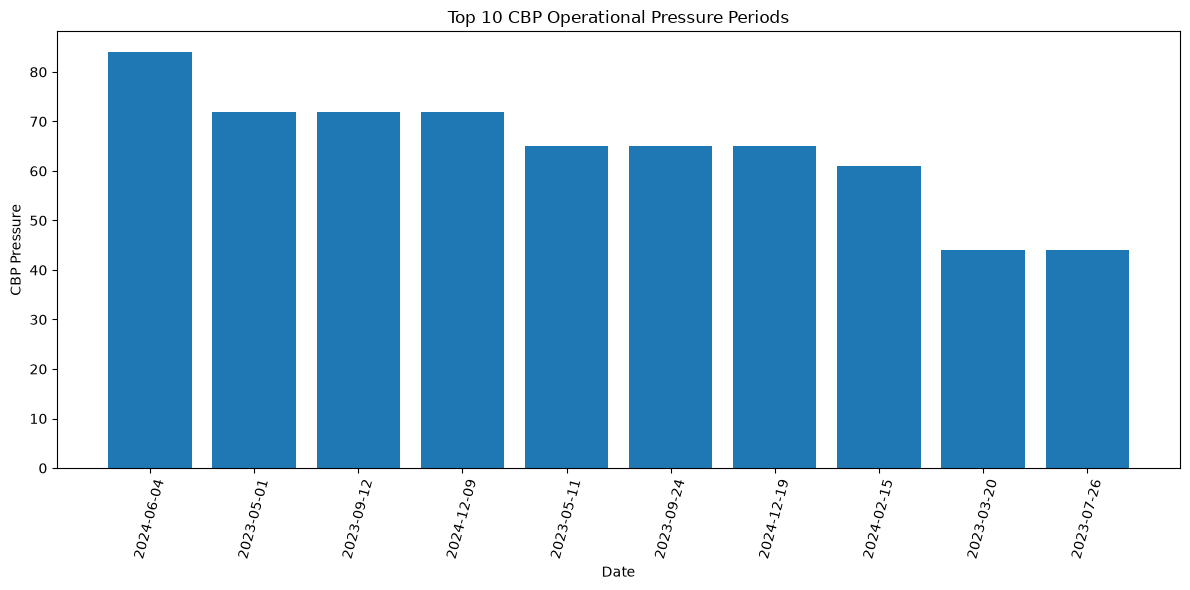

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_cbp_pressure["date"].dt.strftime("%Y-%m-%d"),
    top_cbp_pressure["cbp_pressure"]
)

plt.title("Top 10 CBP Operational Pressure Periods")
plt.xlabel("Date")
plt.ylabel("CBP Pressure")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Figure 8: Top 10 CBP Operational Pressure Periods

### Key Finding

The highest-pressure reporting periods identify specific dates where incoming CBP activity was substantially higher than transfer activity.

### Business Implication

These periods can be used as targeted cases for further operational investigation and comparison with other pipeline indicators.

## Executive Summary

### Key Findings

- The UAC pipeline operates across stages with substantially different population levels.
- Transfer activity varies relative to the CBP custody population.
- Discharge activity varies relative to the HHS care population.
- CBP and HHS operational pressure fluctuate depending on the balance between inflows and outflows.
- Cumulative pressure helps distinguish temporary imbalances from sustained periods of pressure.
- High-pressure reporting periods provide specific points for deeper operational investigation.

### Conclusion

This analaysis evaluates the UAC dataset as a care pipeline rather than only as a collection of population counts. Transfer activity, discharge activity, throughput, and operational pressure provide complementary measures for understanding movement through the system.

The analysis identifies where inflows and outflows become imbalanced and highlights periods that may require closer operational review. However, because the dataset contains aggregate reporting measures rather than individual case-level timestamps, the results should be interpreted as indicators of operational activity and pressure rather than direct measures of processing time or individual placement outcomes.